In [22]:
%load_ext autoreload
%autoreload 2

import sys
import featuregraph as fg
from featuregraph.behaviors.transition2 import Transition

from featuregraph.operators.states import (
    rising_state
)

print("Python:", sys.executable)
print("FeatureGraph:", fg.__file__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Python: /usr/local/bin/python
FeatureGraph: /workspaces/featuregraph/src/featuregraph/__init__.py


In [23]:
# create a transition object

In [24]:
diff_lag = 10
eps = 0.01

bidmc = fg.datasets.bidmc(subject=1)

bidmc_transition = Transition(
    bidmc,
    signal="respiration",
    direction='rising',
    op=rising_state,
    group="subject",
    diff_lag=diff_lag,
    eps=eps,
)

df = bidmc_transition.df
df['rate_of_change'] = df['respiration'].diff()
df['max_rate_of_change'] = df.groupby('respiration_id').transform('max')['rate_of_change']

(<Figure size 1600x660 with 3 Axes>,
 array([<Axes: ylabel='respiration'>, <Axes: ylabel='respiration_id'>,
        <Axes: xlabel='Time', ylabel='respiration_rising_rate_of_change'>],
       dtype=object))

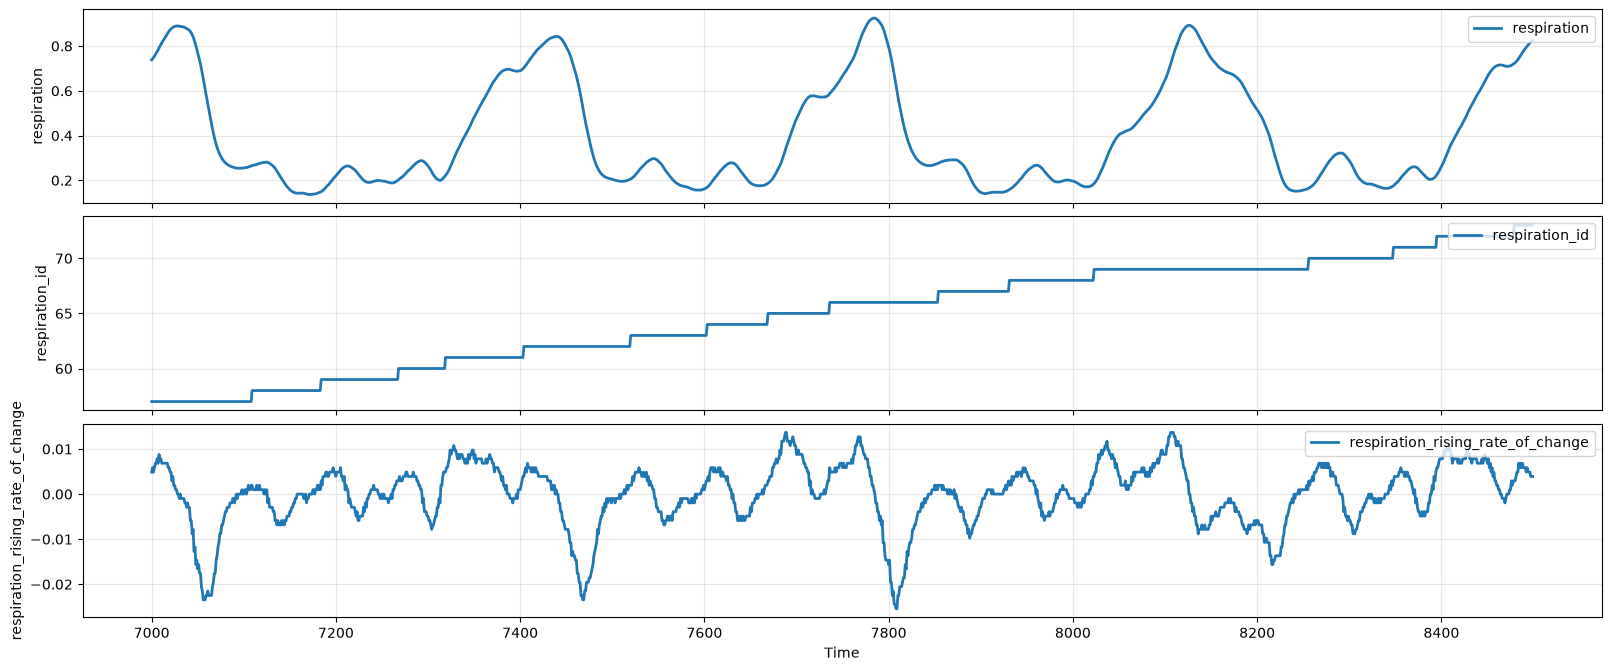

In [25]:
fg.plot(df[7000:8500], [['respiration'],
                            #   ['respiration_rising'],
                            #   ['enter_respiration_rising'],
                            #   ['exit_respiration_rising'],
                              ['respiration_id'],
                              ['respiration_rising_rate_of_change']
                             ]
)

In [26]:
summarydf = bidmc_transition.summary()

In [27]:
summarydf[50:80]

,duration,start_value,end_value,peak_rate_of_change,net_change,mean_rate
respiration_id,,,,,,
50,59,0.52395,0.29032,0.01173,-0.23363,-0.003960
51,17,0.29228,0.17791,0.00196,-0.11437,-0.006728
52,31,0.17986,0.17693,0.00391,-0.00293,-0.000095
53,112,0.18182,0.14370,0.01173,-0.03812,-0.000340
54,48,0.14565,0.18280,0.00587,0.03715,0.000774
55,30,0.18573,0.19550,0.00684,0.00977,0.000326
56,69,0.20039,0.66373,0.01076,0.46334,0.006715
57,46,0.66764,0.26393,0.00880,-0.40371,-0.008776
58,15,0.26588,0.14663,0.00196,-0.11925,-0.007950
